In [1]:
#!/usr/bin/env python
# coding: utf-8

Set seeds for reproducibility

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import h5py
import os
import scipy.io
from scipy.interpolate import interp1d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import random
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
tf.random.set_seed(42)  # For TensorFlow


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Optionally, set TensorFlow to deterministic mode for even more reproducibility

In [2]:
os.environ['TF_DETERMINISTIC_OPS'] = '1'

Function to generate file names based on the input format

In [3]:
name_format = "FCNN_Bz_noprep_run19"
print("Note: use results16.mat which has 10000 datasets; B only has positive Z values")
file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results16.mat which has 10000 datasets; B only has positive Z values


Define the list of files that should be processed as HDF5 files

In [4]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [5]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [6]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [7]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [8]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [9]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

Example usage

In [10]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

Processing results16.mat as a .mat file...


Data is now loaded and processed.

In [11]:
print("Data reading completed.")

Data reading completed.


Flatten the I_data to use as input for the neural network

In [12]:
I_data_flat = I_data.reshape(I_data.shape[0], -1)

Stack only non-zero B and E components to create the output (target) data

In [13]:
target_data = np.column_stack((B_MAG_data[:, 2], EDC_MAG_data))

Split the data into training and testing sets

In [14]:
I_train, I_test, target_train, target_test = train_test_split(I_data_flat, target_data, test_size=0.2, random_state=42)

Only the B3 component is used for training now

In [19]:
B_train = target_train[:, :1]
E_train = target_train[:, 1:]
B_test = target_test[:, :1]
E_test = target_test[:, 1:]

In [16]:
scaler_B3 = MinMaxScaler()
B_train_scaled = scaler_B3.fit_transform(B_train)
B_test_scaled = scaler_B3.transform(B_test)

In [17]:
scaler_E1 = MinMaxScaler()
scaler_E2 = MinMaxScaler()
scaler_E3 = MinMaxScaler()

In [18]:
E_train_scaled = np.column_stack((
    scaler_E1.fit_transform(E_train[:, 0].reshape(-1, 1)),
    scaler_E2.fit_transform(E_train[:, 1].reshape(-1, 1)),
    scaler_E3.fit_transform(E_train[:, 2].reshape(-1, 1))
))
E_test_scaled = np.column_stack((
    scaler_E1.transform(E_test[:, 0].reshape(-1, 1)),
    scaler_E2.transform(E_test[:, 1].reshape(-1, 1)),
    scaler_E3.transform(E_test[:, 2].reshape(-1, 1))
))

In [19]:
target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))

In [20]:
from tensorflow.keras.callbacks import Callback
class LossMonitor(Callback):
    def on_batch_end(self, batch, logs=None):
        if batch % 100 == 0:
            print(f"Batch {batch}: loss = {logs['loss']}")

Define the model

In [25]:
model = Sequential([
    # Reduced dropout and regularization, introduced Swish activation
    Dense(512, kernel_regularizer=l2(0.0005)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),  # Reduced dropout further
    
    Dense(256, kernel_regularizer=l2(0.0003)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),
    
    Dense(128, kernel_regularizer=l2(0.0001)),  # Reduced regularization in the later layers
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.1),  # Minimal dropout for smaller layer
    
    Dense(64, kernel_regularizer=l2(0.0001), activation='swish'),
    Dropout(0.1),  # Further reduced dropout
    
    Dense(32, activation='swish'), # No regularization, small dropout for the final layer
    
    Dense(16, activation='swish'),
    Dense(4)  # Output layer
])

In [26]:
def custom_loss(y_true, y_pred):
    B_true, E_true = y_true[:, :1], y_true[:, 1:]
    B_pred, E_pred = y_pred[:, :1], y_pred[:, 1:]
    loss_B = tf.reduce_mean(tf.square(B_true - B_pred), axis=0)
    loss_E = tf.reduce_mean(tf.square(E_true - E_pred), axis=0)
    weight_B = tf.constant([1.0])
    weight_E = tf.constant([1.0, 1.0, 1.0])
    total_loss = tf.reduce_sum(weight_B * loss_B) + tf.reduce_sum(weight_E * loss_E)
    return total_loss

Compile the model

In [27]:
model.compile(optimizer=RMSprop(learning_rate=0.0005), loss=custom_loss, metrics=['mse'])

Define learning rate scheduler and early stopping

In [28]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [29]:
import time

Measure the time taken for the entire prediction process

In [ ]:
start_time = time.time()

Train the model

In [ ]:
# history = model.fit(
#     I_train, 
#     target_train_scaled, 
#     epochs=400, 
#     batch_size=32, 
#     validation_split=0.2, 
#     callbacks=[lr_scheduler, early_stopping, LossMonitor()]
# )

Measure the end time

In [ ]:
end_time = time.time()

Calculate and print the time taken

In [30]:
time_taken = end_time - start_time
print(f"Time taken for training: {time_taken:.6f} seconds")
print("Training done.", flush=True)

NameError: name 'end_time' is not defined

Save the trained model

In [31]:
model_save_path = os.path.join("/home/botingl/machine learning", generate_filename("model", "h5"))
# model.save(model_save_path)
print("Model saved successfully.")

Model saved successfully.


Load the model

In [32]:
model = tf.keras.models.load_model(model_save_path, custom_objects={'custom_loss': custom_loss})
print("Model loaded successfully.")

Model loaded successfully.


Whole model evaluation (NMSE, rMAE, R²)

In [33]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

Component-wise evaluation (MSE, MAE, R²)

In [34]:
def evaluate_components(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

Evaluation metrics for the training data

In [35]:
print("Start to evaluate the training set.", flush=True)
# Set size based on the length of I_train
size = len(I_train) if len(I_train) < 1000 else 1000
train_subset_indices = np.random.choice(len(I_train), size=size, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]

Start to evaluate the training set.


Measure the time taken for the entire prediction process

In [36]:
start_time = time.time()

In [37]:
predictions_train = model.predict(train_input_data_subset)

32/32 [==============================] - 0s 2ms/step


Measure the end time

In [38]:
end_time = time.time()

In [39]:
time_taken = end_time - start_time

In [40]:
num_input = len(train_input_data_subset)

In [41]:
time_each = time_taken/num_input
print(f"Time taken for prediction on each training set: {time_each:.6f} seconds")

Time taken for prediction on each training set: 0.001217 seconds


Scale back the predicted values to original range

In [42]:
B_pred_train = scaler_B3.inverse_transform(predictions_train[:, 0].reshape(-1, 1))
E_pred_train = np.column_stack((
    scaler_E1.inverse_transform(predictions_train[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_train[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_train[:, 3].reshape(-1, 1))
))

Scale back the true values to original range

In [43]:
B_true_train = scaler_B3.inverse_transform(train_target_data_subset[:, 0].reshape(-1, 1))
E_true_train = np.column_stack((
    scaler_E1.inverse_transform(train_target_data_subset[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(train_target_data_subset[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(train_target_data_subset[:, 3].reshape(-1, 1))
))

Combine the scaled-back true and predicted values for evaluation

In [44]:
true_train_combined = np.column_stack((B_true_train, E_true_train))
pred_train_combined = np.column_stack((B_pred_train, E_pred_train))

Whole model evaluation

In [45]:
nmse_train, rmae_train, r2_whole_model_train = evaluate_whole_model(true_train_combined, pred_train_combined)
print(f"Whole Model NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}")

Whole Model NMSE: 0.016754513011228052, rMAE: 0.05789874518312078, R²: 0.9766954119731689


Component-wise evaluation

In [46]:
mse_train_B3, mae_train_B3, r2_train_B3 = evaluate_components(B_true_train, B_pred_train)
mse_train_E1, mae_train_E1, r2_train_E1 = evaluate_components(E_true_train[:, 0], E_pred_train[:, 0])
mse_train_E2, mae_train_E2, r2_train_E2 = evaluate_components(E_true_train[:, 1], E_pred_train[:, 1])
mse_train_E3, mae_train_E3, r2_train_E3 = evaluate_components(E_true_train[:, 2], E_pred_train[:, 2])

Output the evaluation for each component

In [47]:
print(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}")
print(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}")
print(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}")
print(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}")

B3: MSE = 3.537909282474687e-05, MAE = 0.004360263073854358, R² = 0.9952384269707145
E1: MSE = 15506.128024218458, MAE = 74.51461588449168, R² = 0.9530687171447136
E2: MSE = 2913.5166972992383, MAE = 37.16359870443659, R² = 0.9913029932059666
E3: MSE = 11167.879403310015, MAE = 63.24109759987188, R² = 0.9671715105712808


Save evaluation metrics to a text file

In [48]:
metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_train", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_train}, rMAE: {rmae_train}, R²: {r2_whole_model_train}\n")
    f.write(f"B3: MSE = {mse_train_B3}, MAE = {mae_train_B3}, R² = {r2_train_B3}\n")
    f.write(f"E1: MSE = {mse_train_E1}, MAE = {mae_train_E1}, R² = {r2_train_E1}\n")
    f.write(f"E2: MSE = {mse_train_E2}, MAE = {mae_train_E2}, R² = {r2_train_E2}\n")
    f.write(f"E3: MSE = {mse_train_E3}, MAE = {mae_train_E3}, R² = {r2_train_E3}\n")

Plot the true vs. predicted B and E values for the training set

Text(0.5, 1.0, 'True vs. Predicted B3 (Train)')

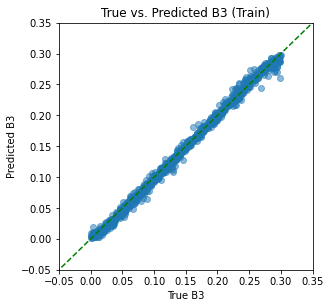

In [49]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_train, B_pred_train, alpha=0.5)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Train)')

Text(0.5, 1.0, 'True vs. Predicted E1 (Train)')

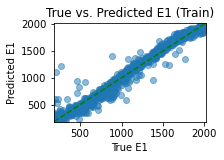

In [50]:
plt.subplot(2, 2, 2)
plt.scatter(E_true_train[:, 0], E_pred_train[:, 0], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Train)')

Text(0.5, 1.0, 'True vs. Predicted E2 (Train)')

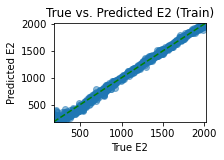

In [51]:
plt.subplot(2, 2, 3)
plt.scatter(E_true_train[:, 1], E_pred_train[:, 1], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Train)')

Text(0.5, 1.0, 'True vs. Predicted E3 (Train)')

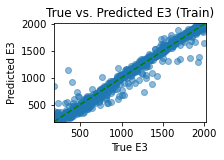

In [52]:
plt.subplot(2, 2, 4)
plt.scatter(E_true_train[:, 2], E_pred_train[:, 2], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Train)')

Add a title for the entire figure

In [53]:
plt.suptitle(f'{name_format}_train', fontsize=16)

Text(0.5, 0.98, 'FCNN_Bz_noprep_run19_train')

<Figure size 432x288 with 0 Axes>

Adjust layout and save the figure

In [54]:
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

<Figure size 432x288 with 0 Axes>

In [55]:
print("Training set evaluation done.", flush=True)

Training set evaluation done.


Evaluate the model on the testing set

In [56]:
print("Start to evaluate the testing set.", flush=True)

Start to evaluate the testing set.


In [57]:
predictions_test = model.predict(I_test)

63/63 [==============================] - 0s 2ms/step


Scale back the predicted values to original range for the test data

In [58]:
B_pred_test = scaler_B3.inverse_transform(predictions_test[:, 0].reshape(-1, 1))

In [59]:
E_pred_test = np.column_stack((
    scaler_E1.inverse_transform(predictions_test[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(predictions_test[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(predictions_test[:, 3].reshape(-1, 1))
))

Scale back the true values to original range for the test data

In [60]:
B_true_test = scaler_B3.inverse_transform(target_test_scaled[:, 0].reshape(-1, 1))

In [61]:
E_true_test = np.column_stack((
    scaler_E1.inverse_transform(target_test_scaled[:, 1].reshape(-1, 1)),
    scaler_E2.inverse_transform(target_test_scaled[:, 2].reshape(-1, 1)),
    scaler_E3.inverse_transform(target_test_scaled[:, 3].reshape(-1, 1))
))

Combine the scaled-back true and predicted values for evaluation (test data)

In [62]:
true_test_combined = np.column_stack((B_true_test, E_true_test))
pred_test_combined = np.column_stack((B_pred_test, E_pred_test))

Whole model evaluation

In [63]:
nmse_test, rmae_test, r2_whole_model_test = evaluate_whole_model(true_test_combined, pred_test_combined)
print(f"Whole Model NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}")

Whole Model NMSE: 0.01906274203749674, rMAE: 0.061787502470550315, R²: 0.9735695182372692


Component-wise evaluation

In [64]:
mse_test_B3, mae_test_B3, r2_test_B3 = evaluate_components(B_true_test, B_pred_test)
mse_test_E1, mae_test_E1, r2_test_E1 = evaluate_components(E_true_test[:, 0], E_pred_test[:, 0])
mse_test_E2, mae_test_E2, r2_test_E2 = evaluate_components(E_true_test[:, 1], E_pred_test[:, 1])
mse_test_E3, mae_test_E3, r2_test_E3 = evaluate_components(E_true_test[:, 2], E_pred_test[:, 2])

Output the evaluation for each component

In [65]:
print(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}")
print(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}")
print(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}")
print(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}")

B3: MSE = 4.413584998969354e-05, MAE = 0.004921727450910742, R² = 0.9942459630342891
E1: MSE = 16024.640279360066, MAE = 77.95839865196065, R² = 0.9525705438955036
E2: MSE = 3156.7335888067028, MAE = 38.38887836052681, R² = 0.9902519725060339
E3: MSE = 14340.719572799519, MAE = 70.48478441763835, R² = 0.9572095935132507


Save evaluation metrics to a text file

In [66]:
metrics_train_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_train_file, "w") as f:
    f.write(f"Whole Model: NMSE: {nmse_test}, rMAE: {rmae_test}, R²: {r2_whole_model_test}\n")
    f.write(f"B3: MSE = {mse_test_B3}, MAE = {mae_test_B3}, R² = {r2_test_B3}\n")
    f.write(f"E1: MSE = {mse_test_E1}, MAE = {mae_test_E1}, R² = {r2_test_E1}\n")
    f.write(f"E2: MSE = {mse_test_E2}, MAE = {mae_test_E2}, R² = {r2_test_E2}\n")
    f.write(f"E3: MSE = {mse_test_E3}, MAE = {mae_test_E3}, R² = {r2_test_E3}\n")

Plot the true vs. predicted B and E values for the test set

Text(0.5, 1.0, 'True vs. Predicted B3 (Test)')

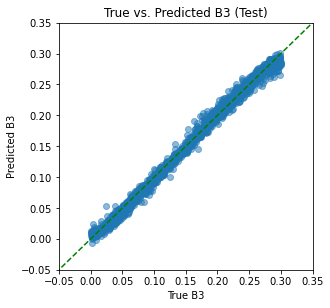

In [67]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.scatter(B_true_test, B_pred_test, alpha=0.5)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'g--')
plt.xlim(-0.05, 0.35)
plt.ylim(-0.05, 0.35)
plt.xlabel('True B3')
plt.ylabel('Predicted B3')
plt.title('True vs. Predicted B3 (Test)')

Text(0.5, 1.0, 'True vs. Predicted E1 (Test)')

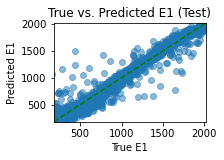

In [68]:
plt.subplot(2, 2, 2)
plt.scatter(E_true_test[:, 0], E_pred_test[:, 0], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E1')
plt.ylabel('Predicted E1')
plt.title('True vs. Predicted E1 (Test)')

Text(0.5, 1.0, 'True vs. Predicted E2 (Test)')

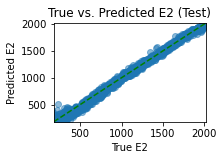

In [69]:
plt.subplot(2, 2, 3)
plt.scatter(E_true_test[:, 1], E_pred_test[:, 1], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E2')
plt.ylabel('Predicted E2')
plt.title('True vs. Predicted E2 (Test)')

Text(0.5, 1.0, 'True vs. Predicted E3 (Test)')

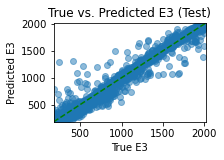

In [70]:
plt.subplot(2, 2, 4)
plt.scatter(E_true_test[:, 2], E_pred_test[:, 2], alpha=0.5)
plt.plot([180, 2020], [180, 2020], 'g--')
plt.xlim(180, 2020)
plt.ylim(180, 2020)
plt.xlabel('True E3')
plt.ylabel('Predicted E3')
plt.title('True vs. Predicted E3 (Test)')

Add a title for the entire figure

In [71]:
plt.suptitle(f'{name_format}_test', fontsize=16)

Text(0.5, 0.98, 'FCNN_Bz_noprep_run19_test')

<Figure size 432x288 with 0 Axes>

Adjust layout and save the figure

In [72]:
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to avoid overlap with suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()

<Figure size 432x288 with 0 Axes>

In [73]:
print("Testing set evaluation done.", flush=True)

Testing set evaluation done.
